Original Image Shape: (300, 300, 1)


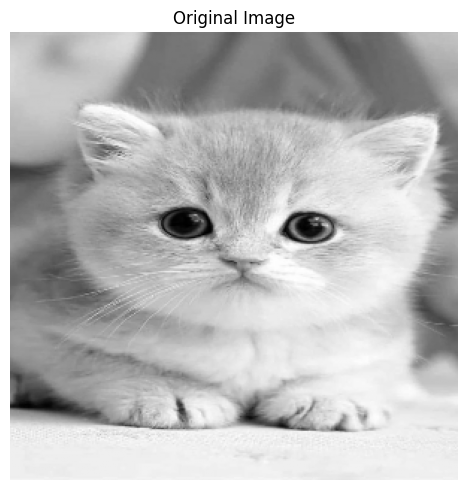

After Convolution Shape: (1, 300, 300, 1)


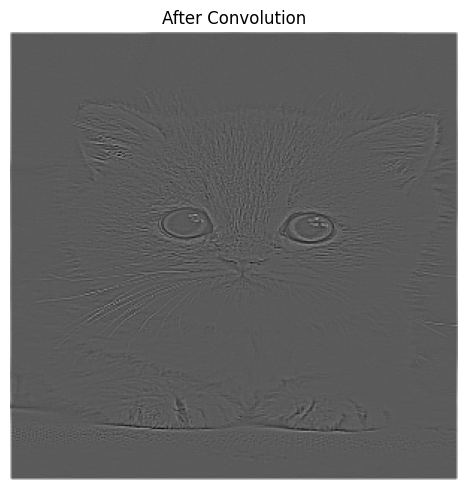

After ReLU Shape: (1, 300, 300, 1)


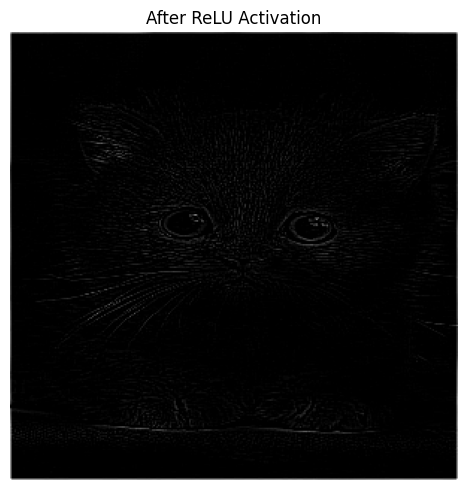

After Pooling Shape: (1, 150, 150, 1)


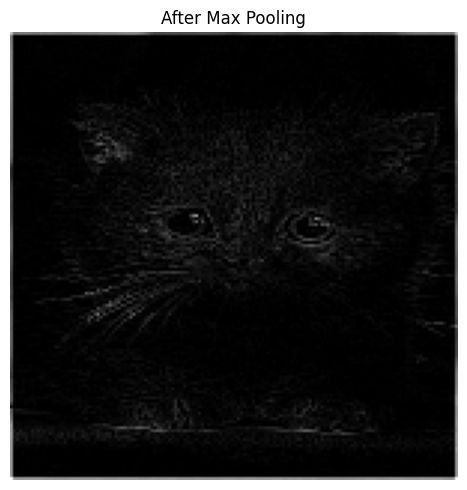

After Flatten Shape: (1, 22500)
First 20 Flattened Values:
[934.57996 554.30383 559.31903 586.80664 585.0399  587.0399  589.0399
 575.0399  575.0399  576.1     589.4783  566.0528  576.05994 579.34393
 580.7071  555.1117  565.95654 556.97986 556.97986 556.97986]
After Fully Connected Layer Shape: (1, 64)


In [3]:
# Import Required Libraries
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rc('image', cmap='gray')
plt.rc('figure', autolayout=True)

# Load and Preprocess the Image
image_path = "image.png"

image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image, channels=1)  
image = tf.image.resize(image, [300, 300])
image = tf.image.convert_image_dtype(image, tf.float32)

print("Original Image Shape:", image.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(image))
plt.title("Original Image")
plt.axis('off')
plt.show()

# Add batch dimension
image = tf.expand_dims(image, axis=0)

# Define Convolution Kernel
kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=tf.float32)

kernel = tf.reshape(kernel, [3, 3, 1, 1])

# Apply Convolution Layer
conv_output = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=1,
    padding='SAME'
)

print("After Convolution Shape:", conv_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(conv_output))
plt.title("After Convolution")
plt.axis('off')
plt.show()

# Apply ReLU Activation Function
relu_output = tf.nn.relu(conv_output)

print("After ReLU Shape:", relu_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(relu_output))
plt.title("After ReLU Activation")
plt.axis('off')
plt.show()

# Apply Max Pooling Layer
pool_output = tf.nn.max_pool2d(
    input=relu_output,
    ksize=2,
    strides=2,
    padding='SAME'
)

print("After Pooling Shape:", pool_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(pool_output))
plt.title("After Max Pooling")
plt.axis('off')
plt.show()

# Apply Flatten Layer
flatten_layer = tf.keras.layers.Flatten()
flatten_output = flatten_layer(pool_output)

print("After Flatten Shape:", flatten_output.shape)

print("First 20 Flattened Values:")
print(flatten_output.numpy()[0][:20])

# Add Fully Connected (Dense) Layer
dense_layer = tf.keras.layers.Dense(
    units=64,         
    activation='relu' 
)

dense_output = dense_layer(flatten_output)

print("After Fully Connected Layer Shape:", dense_output.shape)